# Phase 1 Exploration Report

## Scope
- Phase: Exploratory only (no RL training).
- Focus: trust dynamics, diagnostics, logging contracts, reproducibility.
- Data source: `outputs/phase1` generated by `run_phase1.py`.

In [33]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path('outputs/phase1')
SEED = 2026
steps_path = ROOT / 'steps' / f'seed_{SEED:05d}_steps.parquet'
run_path = ROOT / 'runs' / f'seed_{SEED:05d}_summary.parquet'
agg_path = ROOT / 'aggregate' / 'run_index.parquet'

assert steps_path.exists(), f'Missing: {steps_path}'
assert run_path.exists(), f'Missing: {run_path}'
assert agg_path.exists(), f'Missing: {agg_path}'

steps = pd.read_parquet(steps_path)
run = pd.read_parquet(run_path)
agg = pd.read_parquet(agg_path)

entropy_cols = sorted(
    [c for c in steps.columns if re.fullmatch(r'entropy_\d+', c)],
    key=lambda x: int(x.split('_')[-1]),
)
num_agents = len(entropy_cols)
print(f'Loaded steps: {steps.shape}, run: {run.shape}, agg: {agg.shape}, agents: {num_agents}')

Loaded steps: (300, 51), run: (1, 32), agg: (5, 32), agents: 5


## Validation Snapshot
- Pipeline status: GO (from `phase-1-validation.py`).
- Reproducibility: deterministic for same seed+config.
- Contracts: schema version included in step/run outputs.

In [34]:
summary = {
    'num_seeds': len(agg),
    'mean_final_asymmetry': float(agg['final_asymmetry'].mean()),
    'std_final_asymmetry': float(agg['final_asymmetry'].std()),
    'mean_run_duration_seconds': float(agg['run_duration_seconds'].mean()),
    'predictor_mode': run.loc[0, 'predictor_mode'],
    'schema_version': run.loc[0, 'schema_version'],
}
pd.Series(summary).to_frame('value')

,value
num_seeds,5
mean_final_asymmetry,0.001853
std_final_asymmetry,0.000597
mean_run_duration_seconds,0.154108
predictor_mode,moving_average
schema_version,1.0.0


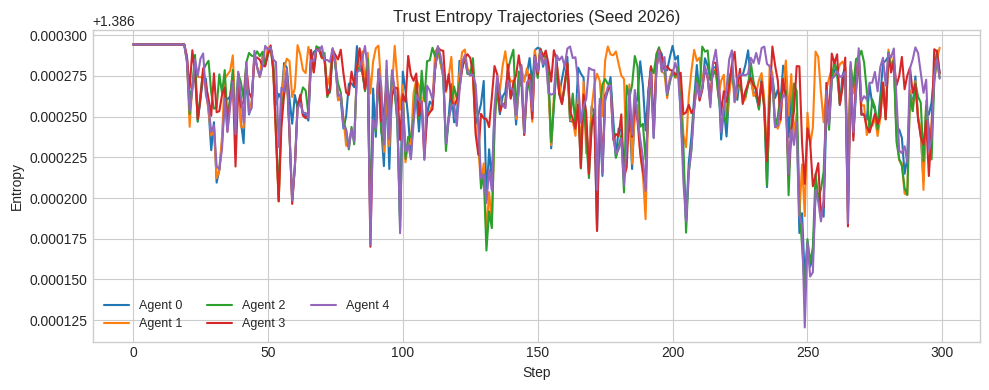

In [35]:
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(num_agents):
    ax.plot(steps['step'], steps[f'entropy_{i}'], label=f'Agent {i}')
ax.set_title('Trust Entropy Trajectories (Seed 2026)')
ax.set_xlabel('Step')
ax.set_ylabel('Entropy')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

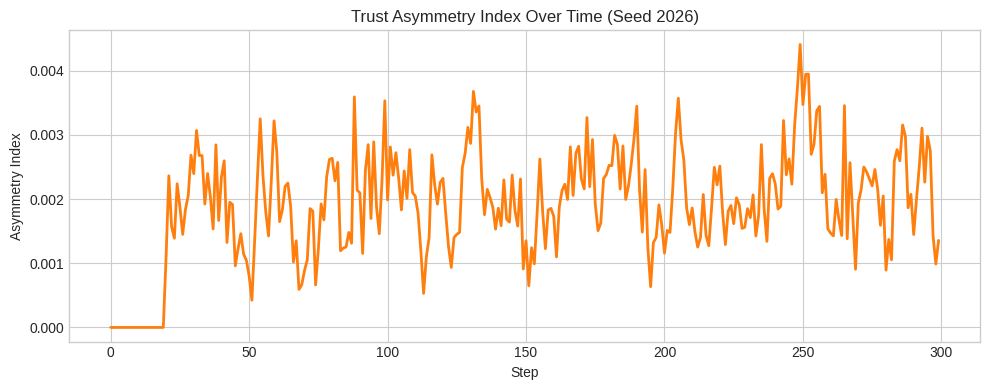

In [36]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps['step'], steps['asymmetry_index'], color='tab:orange', lw=2)
ax.set_title('Trust Asymmetry Index Over Time (Seed 2026)')
ax.set_xlabel('Step')
ax.set_ylabel('Asymmetry Index')
plt.tight_layout()
plt.show()

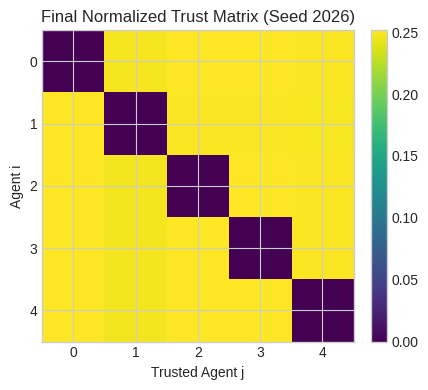

In [37]:
final_row = steps.iloc[-1]
tau = np.zeros((num_agents, num_agents), dtype=float)
for i in range(num_agents):
    for j in range(num_agents):
        if i == j:
            continue
        tau[i, j] = final_row[f'tau_{i}_{j}']

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(tau, cmap='viridis')
ax.set_title('Final Normalized Trust Matrix (Seed 2026)')
ax.set_xlabel('Trusted Agent j')
ax.set_ylabel('Agent i')
ax.set_xticks(range(num_agents))
ax.set_yticks(range(num_agents))
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

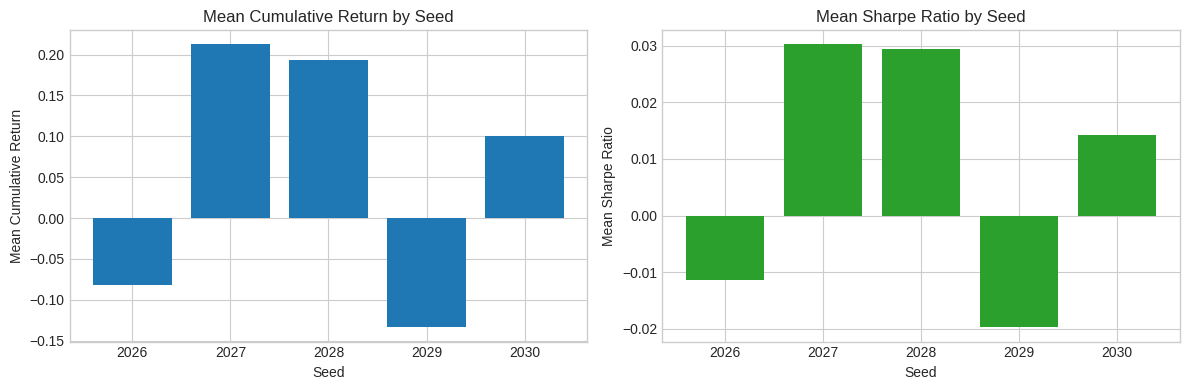

,seed,mean_cumulative_return,mean_sharpe_ratio,final_asymmetry
1,2027,0.212448,0.030238,0.002680
2,2028,0.194056,0.029458,0.002279
4,2030,0.099884,0.014306,0.001351
0,2026,-0.081673,-0.011441,0.001356
3,2029,-0.133965,-0.019778,0.001602


In [38]:
cum_cols = [c for c in agg.columns if c.startswith('cumulative_return_')]
sharpe_cols = [c for c in agg.columns if c.startswith('sharpe_ratio_')]

agg_plot = agg[['seed', 'final_asymmetry'] + cum_cols + sharpe_cols].copy()
agg_plot['mean_cumulative_return'] = agg_plot[cum_cols].mean(axis=1)
agg_plot['mean_sharpe_ratio'] = agg_plot[sharpe_cols].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(agg_plot['seed'].astype(str), agg_plot['mean_cumulative_return'], color='tab:blue')
axes[0].set_title('Mean Cumulative Return by Seed')
axes[0].set_xlabel('Seed')
axes[0].set_ylabel('Mean Cumulative Return')

axes[1].bar(agg_plot['seed'].astype(str), agg_plot['mean_sharpe_ratio'], color='tab:green')
axes[1].set_title('Mean Sharpe Ratio by Seed')
axes[1].set_xlabel('Seed')
axes[1].set_ylabel('Mean Sharpe Ratio')

plt.tight_layout()
plt.show()

agg_plot[['seed', 'mean_cumulative_return', 'mean_sharpe_ratio', 'final_asymmetry']].sort_values('mean_cumulative_return', ascending=False)

In [39]:
# Diagnostics: Print underlying values for sanity check
import numpy as np
print('--- Entropy (first 5 rows) ---')
print(steps[[c for c in steps.columns if c.startswith('entropy_')]].head())
print('--- Entropy (last 5 rows) ---')
print(steps[[c for c in steps.columns if c.startswith('entropy_')]].tail())
print('--- Asymmetry index (min, max, mean) ---')
print(steps['asymmetry_index'].min(), steps['asymmetry_index'].max(), steps['asymmetry_index'].mean())
print('--- Final trust matrix ---')
print(tau)
print('--- Mean cumulative return ---')
print(agg_plot['mean_cumulative_return'].values)
print('--- Mean Sharpe ratio ---')
print(agg_plot['mean_sharpe_ratio'].values)
print('--- Summary ---')
print(summary)

--- Entropy (first 5 rows) ---
   entropy_0  entropy_1  entropy_2  entropy_3  entropy_4  entropy_slope_0  \
0   1.386294   1.386294   1.386294   1.386294   1.386294              NaN   
1   1.386294   1.386294   1.386294   1.386294   1.386294              NaN   
2   1.386294   1.386294   1.386294   1.386294   1.386294              NaN   
3   1.386294   1.386294   1.386294   1.386294   1.386294              NaN   
4   1.386294   1.386294   1.386294   1.386294   1.386294              NaN   

   entropy_slope_1  entropy_slope_2  entropy_slope_3  entropy_slope_4  
0              NaN              NaN              NaN              NaN  
1              NaN              NaN              NaN              NaN  
2              NaN              NaN              NaN              NaN  
3              NaN              NaN              NaN              NaN  
4              NaN              NaN              NaN              NaN  
--- Entropy (last 5 rows) ---
     entropy_0  entropy_1  entropy_2  entrop

## Phase 1 Conclusions
- Trust diagnostics pipeline is stable and reproducible.
- Convergence appears early and consistent for the default setup.
- Asymmetry remains low under default moving-average predictor.
- Logging contracts are now versioned (`schema_version=1.0.0`).
- Phase 2 can proceed with baseline RL while preserving these interfaces.